In [3]:
import pandas as pd
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(os.path.dirname(os.getcwd()))

# 读取数据
df = pd.read_csv("input/ukb/ukb_covreg1_trans1_nanf1_biom0.csv")

# 目标变量y和特征矩阵X
y = df['stage'].values
X = df.iloc[:, 7:].values  # 假设特征从第8列开始


In [4]:
import pandas as pd
from sklearn.linear_model import LassoCV
import numpy as np
import matplotlib.pyplot as plt

# --- 假设数据 X 和 y 已经准备好 ---
# y = df['stage'].values
# X = df.iloc[:, 7:].values

rough_alpha = 0.01174388887841015
print(f"初步探测的最优 alpha: {rough_alpha}")

# 2. 第二步：以该 alpha 为中心，构建更广泛、更精细的搜索范围
# np.logspace 创建对数等比数列
# 范围：从 optimal_alpha 的 1/100 到 100倍 (根据需要调整 -2 和 +2)
alphas_refined = np.logspace(
    np.log10(rough_alpha) - 2, 
    np.log10(rough_alpha) + 2, 
    100
)

# 3. 第三步：使用自定义的 alphas 重新拟合
# 注意：这里我们传入具体的 alphas 参数
lasso_cv = LassoCV(alphas=alphas_refined, cv=5, n_jobs=-1, random_state=42)
lasso_cv.fit(X, y)

save_path = 'output/result_analysis/ukb_MixtureGRBF_cv_nsubtype_biom17/5_subtypes/lasso_result_data.npz'

np.savez(
    save_path,
    alphas=lasso_cv.alphas_,      # X轴数据
    mse_path=lasso_cv.mse_path_,  # 用于计算均值和方差的数据
    best_alpha=lasso_cv.alpha_    # 标记最优值的垂直线
)



初步探测的最优 alpha: 0.01174388887841015


/data/users/junru/MixtureGRBF/env_tmp/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 308.3879743180587, tolerance: 164.64743488343655
  model = cd_fast.enet_coordinate_descent_gram(
/data/users/junru/MixtureGRBF/env_tmp/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 300.40078892122256, tolerance: 164.64743488343655
  model = cd_fast.enet_coordinate_descent_gram(
/data/users/junru/MixtureGRBF/env_tmp/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 279.86261331127025, tolerance: 163.81580559178352
  model = cd_fast.enet_coordinate_descent_gram(
/data/users/junru/Mi

KeyboardInterrupt: 

/data/users/junru/MixtureGRBF/env_tmp/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1140.6509296309086, tolerance: 164.54164108249103
  model = cd_fast.enet_coordinate_descent_gram(
/data/users/junru/MixtureGRBF/env_tmp/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 444.8233495739987, tolerance: 163.37265196853605
  model = cd_fast.enet_coordinate_descent_gram(
/data/users/junru/MixtureGRBF/env_tmp/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1745.1089360275655, tolerance: 164.64743488343655
  model = cd_fast.enet_coordinate_descent_gram(
/data/users/junru/Mi

已加载数据。最优 Alpha: 0.01174388887841015


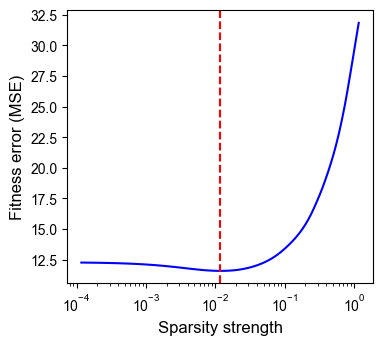

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# import os
# os.chdir(os.path.dirname(os.getcwd()))

exp_name = 'ukb_MixtureGRBF_cv_nsubtype_biom17'
nsubtype = 5
output_path = f'output/result_analysis/{exp_name}/{nsubtype}_subtypes/lasso_sparsity.png'

plt.rcParams.update({
    'font.family': 'sans-serif',  # 指定字体家族为无衬线
    'font.sans-serif': ['Arial'], # 在无衬线字体列表中首选 Arial
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 8
})


file_path = 'output/result_analysis/ukb_MixtureGRBF_cv_nsubtype_biom17/5_subtypes/lasso_result_data.npz'
data = np.load(file_path)

alphas = data['alphas']
mse_path = data['mse_path']
best_alpha = 0.01174388887841015

print(f"已加载数据。最优 Alpha: {best_alpha}")

mse_mean = np.mean(mse_path, axis=1)
mse_std = np.std(mse_path, axis=1)

plt.figure(figsize=(10/2.54, 9/2.54))

# 绘制 MSE 曲线
plt.plot(alphas, mse_mean, linestyle='-', color='b', label='Average MSE')


# 标记最优 Alpha
plt.axvline(best_alpha, linestyle='--', color='r', label=f'Optimal Alpha: {best_alpha:.2e}')

# 设置坐标轴
plt.xscale('log') 
plt.xticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0])
# plt.minorticks_off() 
plt.xlabel('Sparsity strength')
plt.ylabel('Fitness error (MSE)')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()


